In [180]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('dataset/googleplaystore_cleaned.csv')

In [181]:
# Handle 'Varies with device' in 'Size' column
df['Size_varies'] = (df['Size'] == 'Varies with device').astype(int)
df['Size'] = pd.to_numeric(df['Size'], errors='coerce')

# Fill based on the median size of apps in the same category
df['Size'] = df.groupby('Category')['Size'].transform(
  lambda x: x.fillna(x.median())
)

# Fallback: Fill any remaining NaN values in 'Size' with the overall median
df['Size'].fillna(df['Size'].median(), inplace=True)

In [182]:
print(df[['Price', 'Rating']].corr())

           Price    Rating
Price   1.000000 -0.023334
Rating -0.023334  1.000000


In [183]:
df['Log_Installs'] = np.log1p(df['Installs']+1)
df['Log_Reviews'] = np.log1p(df['Reviews']+1)
df['Log_Size'] = np.log1p(df['Size']+1)

# if Rating is 0, set it to 1e-5 to avoid division by zero
df['Rating'] = df['Rating'].replace(0, 1e-15)

df['Premium_Penalty'] = df['Price'] * (1 / df['Rating'])

features = [
    'Log_Reviews',
    'Log_Installs',
    'Rating',
    'Price',
    'Log_Size',
]

X = df[features]
X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_
variance_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Explained Variance Ratio': explained_variance
})
variance_df

,Principal Component,Explained Variance Ratio
0,PC1,0.477596
1,PC2,0.199748
2,PC3,0.187222
3,PC4,0.126989
4,PC5,0.008445


In [184]:
components_df = pd.DataFrame(
    pca.components_,
    columns=features,
    index=[f'PC{i+1}' for i in range(len(explained_variance))]
)
components_df

,Log_Reviews,Log_Installs,Rating,Price,Log_Size
PC1,0.614328,0.612849,0.421180,-0.053132,0.258461
PC2,0.043739,0.032671,0.112500,0.978571,-0.163592
PC3,-0.019320,-0.060188,-0.405452,0.198289,0.890109
PC4,-0.344457,-0.349710,0.803434,-0.008981,0.336848
PC5,0.708283,-0.705287,0.007415,-0.013306,-0.025975


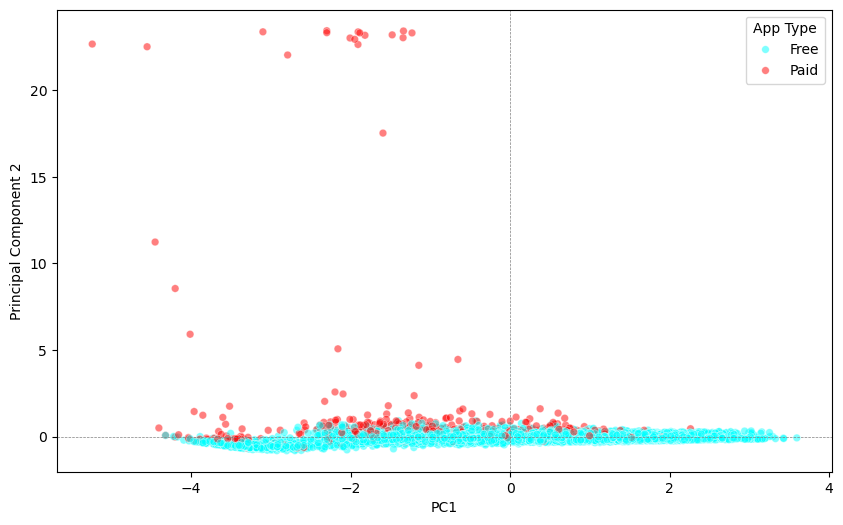

In [185]:
# Plotting
pca_2d = pca.transform(X_scaled)

pca_df = pd.DataFrame({
  'PC1': pca_2d[:, 0],
  'PC2': pca_2d[:, 1],
  'PC3': pca_2d[:, 2],
  'PC4': pca_2d[:, 3],
  'App_type' : df['Type']
})

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='App_type',
    data=pca_df,
    palette={'Free': 'cyan', 'Paid': 'red'},
    alpha=0.5,
    s=30
)
plt.legend(title='App Type')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.5)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.5)
plt.ylabel('Principal Component 2')
plt.show()


#### Subproblem

Identify the following:
1. What are the top performing apps?
2. What are the paid apps that are hits?
3. What are the free apps that are misses?
4. What are the paid apps with low price penalty?
5. What are the paid apps with high price penalty?

In [186]:
pca_df['App'] = df['App']

# Top 10 apps with best quality (highest PC1)
pca_df[[ 'App', 'PC1' ]].sort_values(by='PC1', ascending=False).head(10)


,App,PC1
1356,Subway Surfers,3.593424
1372,Clash of Clans,3.428826
1357,Candy Crush Saga,3.424809
1362,Clash Royale,3.326451
342,UC Browser - Fast Download Private & Secure,3.293373
1410,My Talking Tom,3.256374
2003,Instagram,3.250662
1363,Temple Run 2,3.200689
1527,Shadow Fight 2,3.193344
1399,My Talking Angela,3.168778


In [187]:
# top performing paid apps
pca_df[pca_df['App_type'] == 'Paid'][[ 'App', 'PC1' ]].sort_values(by='PC1', ascending=False).head(10)

,App,PC1
1743,Minecraft,2.260596
3208,Hitman Sniper,2.135376
7743,Bloons TD 5,1.936158
8538,Where's My Water?,1.906705
4526,True Skate,1.761361
4650,Five Nights at Freddy's,1.707755
6370,Grand Theft Auto: San Andreas,1.678840
8050,Stickman Legends: Shadow Wars,1.647000
8045,League of Stickman 2018- Ninja Arena PVP(Dream...,1.619580
3375,Cut the Rope GOLD,1.607120


In [188]:
# Worst performing free apps
pca_df[pca_df['App_type'] == 'Free'][[ 'App', 'PC1' ]].sort_values(by='PC1', ascending=True).head(10)

,App,PC1
8212,qEG APP / Química EG SRL,-4.321618
5719,BS TRACK CLIENT,-4.221860
5642,4-T's Bar-BQ & Catering,-4.171778
6323,mySharpBranded CI Test,-4.093825
7754,Test Application DT 02,-4.028112
8519,EO SA Benefits,-4.013791
8182,EF First,-3.967804
8081,EB Experience,-3.943106
7519,Sweden Newspapers,-3.910778
5241,Lexus Tech BH Service Pro,-3.897236


In [189]:
# Worst performing paid apps
pca_df[pca_df['App_type'] == 'Paid'][[ 'App', 'PC1', 'PC2' ]].sort_values(by='PC1', ascending=True).head(10)

,App,PC1,PC2
8763,Eu Sou Rico,-5.241200,22.664104
8780,I'm Rich/Eu sou Rico/أنا غني/我很有錢,-4.553478,22.509189
8577,EP Cook Book,-4.453018,11.231097
409,"Private Dating, Hide App- Blue for PrivacyHider",-4.405861,0.494588
6343,CI Attendance,-4.322630,0.070887
4847,¡Ay Caramba!,-4.203103,-0.030563
5661,cronometra-br,-4.201309,8.547828
6953,CW Ringtone (Morse Code generator),-4.158455,0.103168
5290,BI Barcode Scanner,-4.035914,-0.058507
8086,Schlaumeier,-4.033423,-0.112165


In [190]:
# Most most expensive apps (PC2) with high price and low rating
pca_df[[ 'App', 'PC2', 'PC1' ]].sort_values(by='PC2', ascending=False).head(10)

,App,PC2,PC1
4403,I am rich(premium),23.433516,-2.300580
4396,I am rich,23.418557,-1.338720
3327,most expensive app (H),23.370023,-3.101299
4406,I Am Rich Pro,23.364937,-1.907712
4408,I am rich (Most expensive app),23.321410,-2.300439
4413,I am Rich,23.309465,-1.885896
4400,I Am Rich Premium,23.305755,-1.231785
4398,I am Rich Plus,23.194588,-1.480219
3469,I'm Rich - Trump Edition,23.170649,-1.821483
3465,💎 I'm rich,23.029424,-1.343683


In [191]:
# Worst performing expensive apps (high PC2 but low PC1)
pca_df[(pca_df['PC2'] > 0) & (pca_df['PC1'] < 0)][[ 'App', 'PC2', 'PC1' ]].sort_values(by='PC2', ascending=False).head(10)

,App,PC2,PC1
4403,I am rich(premium),23.433516,-2.300580
4396,I am rich,23.418557,-1.338720
3327,most expensive app (H),23.370023,-3.101299
4406,I Am Rich Pro,23.364937,-1.907712
4408,I am rich (Most expensive app),23.321410,-2.300439
4413,I am Rich,23.309465,-1.885896
4400,I Am Rich Premium,23.305755,-1.231785
4398,I am Rich Plus,23.194588,-1.480219
3469,I'm Rich - Trump Edition,23.170649,-1.821483
3465,💎 I'm rich,23.029424,-1.343683
